In [96]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler

In [97]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [98]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [99]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [100]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [101]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [102]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [103]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [104]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [105]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [106]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [107]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [108]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [109]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [110]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [111]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

## Standardization for Clustering

In [112]:
original_X = X.copy()

In [113]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [114]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,0.461898,0.499075,0.224562,0.350904,0.324971,0.329524,0.197367,0.298726,0.054040,0.236549,...,0.103491,0.073737,0.246552,0.828332,0.000000,0.146370,0.174091,0.088609,0.117134,0.129992
1,0.829873,0.220565,0.009452,0.123069,0.098241,0.105313,0.112770,0.099559,0.007092,0.167245,...,0.293049,0.527489,0.491288,0.381507,0.000000,0.627983,0.456736,0.501821,0.522593,0.262640
2,0.724738,0.602909,0.323454,0.428640,0.431058,0.394219,0.289334,0.430358,0.098901,0.416103,...,0.000000,0.110703,0.324605,0.844232,0.066875,0.181100,0.097341,0.000000,0.100822,0.147717
3,0.839273,0.284579,0.030943,0.135806,0.084805,0.090131,0.164684,0.145809,0.008753,0.182093,...,0.251423,0.433705,0.502847,0.418154,0.000000,0.237064,0.464144,0.000000,0.385850,0.343574
4,0.814436,0.345369,0.110132,0.254489,0.165934,0.259726,0.189977,0.222333,0.014595,0.290508,...,0.000000,0.125399,0.481924,0.337066,0.386334,0.644928,0.518081,0.572624,0.718823,0.543835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.583257,0.479962,0.141584,0.233413,0.215527,0.254755,0.126540,0.198864,0.026267,0.194288,...,0.000000,0.098308,0.242188,0.782563,0.000000,0.103713,0.242682,0.000000,0.109365,0.126149
135,0.702369,0.831212,0.347022,0.337469,0.361149,0.408289,0.267366,0.351455,0.086360,0.325084,...,0.033028,0.123853,0.382084,0.730419,0.000000,0.294427,0.187835,0.113114,0.172107,0.234892
136,0.720597,0.686245,0.243971,0.279727,0.190136,0.307936,0.291232,0.251133,0.050921,0.280811,...,0.000000,0.020534,0.134210,0.895114,0.000000,0.065712,0.175602,0.000000,0.091309,0.191396
137,0.504667,0.427891,0.225551,0.400455,0.339899,0.348108,0.222720,0.342192,0.061894,0.290628,...,0.000000,0.064801,0.319657,0.711658,0.000000,0.226079,0.265036,0.077871,0.177208,0.265078


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

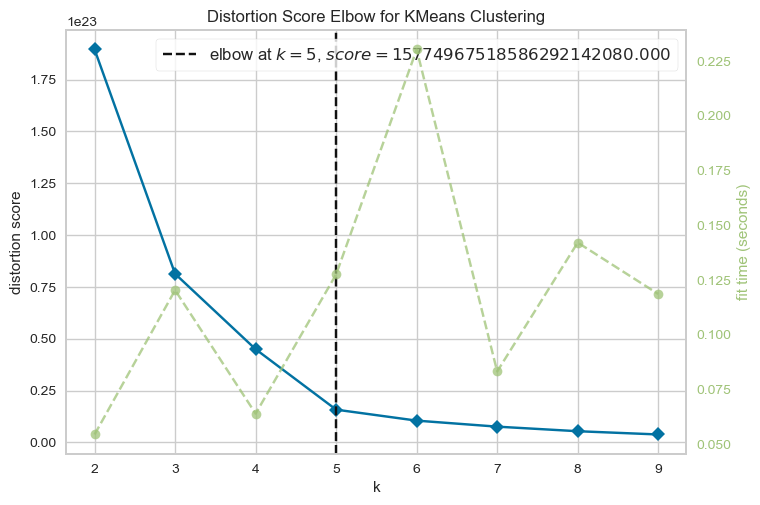

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [115]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [116]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: glcm_Id_d_1_PET_b2, Coefficient: -15.447777582577219


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glrlm_GrayLevelVariance_CT_b20, Coefficient: 14.040932445089998


...

Cluster 2: Most important feature: gldm_DependenceNonUniformity_d_1_PET_c04, Coefficient: -35.55020741170574


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: glcm_Id_d_1_CT_b20, Coefficient: 9.393377723250353


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: first_order_Mean_PET, Coefficient: -8.37336297497252


In [117]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [119]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [120]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [121]:
X_new

,glcm_Id_d_1_PET_b2,glrlm_GrayLevelVariance_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04,glcm_Id_d_1_CT_b20,first_order_Mean_PET
0,0.826905,22.310788,1132.849143,0.594240,7.489228
1,0.902339,20.557318,177.023053,0.630819,3.236345
2,0.917698,21.092104,1888.886026,0.649464,4.223322
3,0.936960,22.786001,211.940366,0.533317,1.952779
4,0.899247,29.182742,346.285373,0.529376,3.774285
...,...,...,...,...,...
134,0.862760,4.906583,517.454513,0.675973,4.805702
135,0.931700,16.015030,1592.627288,0.747190,4.700546
136,0.829673,24.706900,1021.684898,0.702434,6.798946
137,0.916060,5.157909,1295.643252,0.783382,4.828376


In [122]:
X_new_std

,glcm_Id_d_1_PET_b2,glrlm_GrayLevelVariance_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04,glcm_Id_d_1_CT_b20,first_order_Mean_PET
0,0.473776,0.072353,0.016668,0.427691,0.405288
1,0.737560,0.066055,0.001362,0.509661,0.093962
2,0.791268,0.067975,0.028776,0.551445,0.166212
3,0.858627,0.074060,0.001921,0.291164,0.000000
4,0.726747,0.097036,0.004072,0.282333,0.133341
...,...,...,...,...,...
134,0.599157,0.009840,0.006813,0.610852,0.208844
135,0.840233,0.049739,0.024031,0.770445,0.201146
136,0.483455,0.080959,0.014888,0.670148,0.354757
137,0.785541,0.010743,0.019275,0.851550,0.210504


In [123]:
MAASTRO_new

,glcm_Id_d_1_PET_b2,glrlm_GrayLevelVariance_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04,glcm_Id_d_1_CT_b20,first_order_Mean_PET
0,0.833510,14.212485,2486.104657,0.783994,8.620975
1,0.899231,54.975356,1223.288872,0.701545,3.833351
2,0.849754,27.032891,1128.604578,0.744598,6.182864
3,0.897983,146.781623,758.871164,0.541210,4.199987
4,0.911954,9.468732,1924.271323,0.783396,4.872122
...,...,...,...,...,...
94,0.688625,40.637943,803.301749,0.669629,13.222061
95,0.867573,143.812625,1121.977787,0.601945,5.751008
96,0.924211,22.317077,2157.170772,0.740633,4.613887
97,0.854212,20.533289,1866.857748,0.623433,6.385348


In [124]:
MAASTRO_new_std

,glcm_Id_d_1_PET_b2,glrlm_GrayLevelVariance_CT_b20,gldm_DependenceNonUniformity_d_1_PET_c04,glcm_Id_d_1_CT_b20,first_order_Mean_PET
0,0.496872,0.043265,0.038340,0.852920,0.488136
1,0.726691,0.189678,0.018117,0.668156,0.137665
2,0.553678,0.089314,0.016600,0.764637,0.309657
3,0.722327,0.519430,0.010679,0.308852,0.164504
4,0.771182,0.026226,0.029342,0.851582,0.213706
...,...,...,...,...,...
94,-0.009776,0.138181,0.011391,0.596635,0.824951
95,0.615989,0.508766,0.016494,0.444957,0.278044
96,0.814045,0.072375,0.033072,0.755752,0.194802
97,0.569265,0.065968,0.028423,0.493111,0.324480


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [125]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 15:56:10,628] A new study created in memory with name: no-name-ca121a77-37a5-466d-a9cd-b27c06ca4c42


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 15:56:10,874] A new study created in memory with name: no-name-0b92c411-41dd-452e-a166-70d659c17cb6


Fold 1 C-index: 0.4063745019920319
Fold 2 C-index: 0.3992248062015504
Fold 3 C-index: 0.5234042553191489
Fold 4 C-index: 0.4220532319391635
Fold 5 C-index: 0.38197424892703863
[I 2024-04-14 15:56:10,866] Trial 0 finished with value: 0.42660620887578665 and parameters: {}. Best is trial 0 with value: 0.42660620887578665.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.42660620887578665], datetime_start=datetime.datetime(2024, 4, 14, 15, 56, 10, 670426), datetime_complete=datetime.datetime(2024, 4, 14, 15, 56, 10, 865914), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.42660620887578665


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.25736438338876394
Fold 2 IBS: 0.2588586837708546
Fold 3 IBS: 0.23875231567966804
Fold 4 IBS: 0.29016087287039305
Fold 5 IBS: 0.23843033954181464
[I 2024-04-14 15:56:11,150] Trial 0 finished with value: 0.2567133190502988 and parameters: {}. Best is trial 0 with value: 0.2567133190502988.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2567133190502988], datetime_start=datetime.datetime(2024, 4, 14, 15, 56, 10, 923641), datetime_complete=datetime.datetime(2024, 4, 14, 15, 56, 11, 149852), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2567133190502988


In [126]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [127]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.427
train_ibs:  0.257


#### Test

In [128]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [129]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.597
IBS score: 0.224


In [130]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [131]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [132]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:56:12,595] A new study created in memory with name: no-name-555797ee-ae10-4de2-8828-dda024913dd4


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 15:56:12,751] A new study created in memory with name: no-name-7ab72742-bc88-4c53-aec1-d9b7e0b28fa2


Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.42441860465116277
Fold 3 C-index: 0.30425531914893617
Fold 4 C-index: 0.37072243346007605
Fold 5 C-index: 0.41630901287553645
[I 2024-04-14 15:56:12,740] Trial 0 finished with value: 0.3907904764175805 and parameters: {}. Best is trial 0 with value: 0.3907904764175805.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.3907904764175805], datetime_start=datetime.datetime(2024, 4, 14, 15, 56, 12, 648368), datetime_complete=datetime.datetime(2024, 4, 14, 15, 56, 12, 740375), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.3907904764175805


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724710178730816
Fold 2 IBS: 0.23203988527615702
Fold 3 IBS: 0.22898186969881207
Fold 4 IBS: 0.24197477565078476
Fold 5 IBS: 0.22939559374879873
[I 2024-04-14 15:56:12,945] Trial 0 finished with value: 0.23592784523237215 and parameters: {}. Best is trial 0 with value: 0.23592784523237215.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784523237215], datetime_start=datetime.datetime(2024, 4, 14, 15, 56, 12, 798429), datetime_complete=datetime.datetime(2024, 4, 14, 15, 56, 12, 945827), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784523237215


In [133]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [134]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.391
train_ibs:  0.236


#### Test

In [135]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [136]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.502


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [137]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [138]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:56:13,356] A new study created in memory with name: no-name-64fe12c5-db09-4fb4-90a0-75fd75937cfb


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 15:56:13,527] A new study created in memory with name: no-name-5176a466-eb4e-4bc9-babe-b3c8b9ad1798


Fold 1 C-index: 0.3904382470119522
Fold 2 C-index: 0.4806201550387597
Fold 3 C-index: 0.2553191489361702
Fold 4 C-index: 0.3688212927756654
Fold 5 C-index: 0.3948497854077253
[I 2024-04-14 15:56:13,516] Trial 0 finished with value: 0.37800972583405457 and parameters: {}. Best is trial 0 with value: 0.37800972583405457.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.37800972583405457], datetime_start=datetime.datetime(2024, 4, 14, 15, 56, 13, 418486), datetime_complete=datetime.datetime(2024, 4, 14, 15, 56, 13, 516121), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.37800972583405457


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.25018684770616134
Fold 2 IBS: 0.23435603605160088
Fold 3 IBS: 0.24006178766705924
Fold 4 IBS: 0.2559880085628007
Fold 5 IBS: 0.23151975381940607
[I 2024-04-14 15:56:13,827] Trial 0 finished with value: 0.24242248676140563 and parameters: {}. Best is trial 0 with value: 0.24242248676140563.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24242248676140563], datetime_start=datetime.datetime(2024, 4, 14, 15, 56, 13, 611627), datetime_complete=datetime.datetime(2024, 4, 14, 15, 56, 13, 826676), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24242248676140563


In [139]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [140]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.378
train_ibs:  0.242


#### Test

In [141]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [142]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.557


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.228


In [143]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [144]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 15:56:14,149] A new study created in memory with name: no-name-fc3090bd-552c-48d0-8634-68f30f678137


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.40239043824701193
Fold 2 C-index: 0.4728682170542636
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3688212927756654
Fold 5 C-index: 0.38626609442060084
[I 2024-04-14 15:56:14,314] Trial 0 finished with value: 0.3796862297761041 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.3796862297761041.
Fold 1 C-index: 0.41832669322709165
Fold 2 C-index: 0.46511627906976744
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3650190114068441
Fold 5 C-index: 0.38626609442060084
[I 2024-04-14 15:56:14,417] Trial 1 finished with value: 0.3805626369014566 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.3805626369014566.
Fold 1 C-index: 0.4262948207171315
Fold 2 C-index: 0.46511627906976744
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3650190114068441
Fold 5 C-index: 0.38626609442060084
[I 2024-04-14 15:56:14,555] Trial 2 finished with value: 0.38215626239946454 and parameters: {'l1_ratio': 0.22692876841

Fold 2 C-index: 0.4689922480620155
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3650190114068441
Fold 5 C-index: 0.38197424892703863
[I 2024-04-14 15:56:17,386] Trial 24 finished with value: 0.37808902335418176 and parameters: {'l1_ratio': 0.329990397647379}. Best is trial 3 with value: 0.3828119244224116.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.47674418604651164
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3688212927756654
Fold 5 C-index: 0.38197424892703863
[I 2024-04-14 15:56:17,504] Trial 25 finished with value: 0.38358711822086117 and parameters: {'l1_ratio': 0.5088438776079254}. Best is trial 25 with value: 0.38358711822086117.
Fold 1 C-index: 0.4103585657370518
Fold 2 C-index: 0.4728682170542636
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3688212927756654
Fold 5 C-index: 0.38626609442060084
[I 2024-04-14 15:56:17,621] Trial 26 finished with value: 0.38127985527411207 and parameters: {'l1_ratio': 0.6433442231739248}. Best is trial 25 with va

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.47674418604651164
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3688212927756654
Fold 5 C-index: 0.38197424892703863
[I 2024-04-14 15:56:20,124] Trial 48 finished with value: 0.38358711822086117 and parameters: {'l1_ratio': 0.522958270555553}. Best is trial 25 with value: 0.38358711822086117.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.46511627906976744
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3650190114068441
Fold 5 C-index: 0.38626609442060084
[I 2024-04-14 15:56:20,231] Trial 49 finished with value: 0.38135944965046054 and parameters: {'l1_ratio': 0.25032259943812496}. Best is trial 25 with value: 0.38358711822086117.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.47674418604651164
Fold 3 C-index: 0.2680851063829787
Fold 4 C-index: 0.3688212927756654
Fold 5 C-index: 0.38197424892703863
[I 2024-04-14 15:56:20,359] Trial 50 finished with value: 0.38358711822086117 and parameters: {'l1_ratio': 0.5

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.25047232494320004
Fold 2 IBS: 0.23425339513482463
Fold 3 IBS: 0.2371165978217881
Fold 4 IBS: 0.2538644838322836
Fold 5 IBS: 0.23135324378989047
[I 2024-04-14 15:56:27,125] Trial 0 finished with value: 0.24141200910439736 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24141200910439736.
Fold 1 IBS: 0.2496170486117979
Fold 2 IBS: 0.23346289782213453
Fold 3 IBS: 0.2330079965914173
Fold 4 IBS: 0.24913763890978138
Fold 5 IBS: 0.2306618390128328
[I 2024-04-14 15:56:27,236] Trial 1 finished with value: 0.23917748418959278 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.23917748418959278.
Fold 1 IBS: 0.24930423036782615
Fold 2 IBS: 0.23325350166420683
Fold 3 IBS: 0.23226873308373439
Fold 4 IBS: 0.24815734253329047
Fold 5 IBS: 0.23047783485681336
[I 2024-04-14 15:56:27,432] Trial 2 finished with value: 0.23869232850117425 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.23869232850117

Fold 2 IBS: 0.23252292118737236
Fold 3 IBS: 0.2301304374724015
Fold 4 IBS: 0.24458813265526025
Fold 5 IBS: 0.22983161522214118
[I 2024-04-14 15:56:30,925] Trial 25 finished with value: 0.2370356618293544 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.23600520906880815.
Fold 1 IBS: 0.24915853805871344
Fold 2 IBS: 0.23315950899338925
Fold 3 IBS: 0.23195883726933672
Fold 4 IBS: 0.24771512394595208
Fold 5 IBS: 0.23039485197872303
[I 2024-04-14 15:56:31,080] Trial 26 finished with value: 0.2384773720492229 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 0.23600520906880815.
Fold 1 IBS: 0.24793254747610954
Fold 2 IBS: 0.2324237845828909
Fold 3 IBS: 0.22988031567214873
Fold 4 IBS: 0.24407164198390147
Fold 5 IBS: 0.22974529104830002
[I 2024-04-14 15:56:31,236] Trial 27 finished with value: 0.2368107161526701 and parameters: {'l1_ratio': 0.056847137315710346}. Best is trial 13 with value: 0.23600520906880815.
Fold 1 IBS: 0.25043

Fold 1 IBS: 0.247326819370801
Fold 2 IBS: 0.23208384643815222
Fold 3 IBS: 0.22907950504247038
Fold 4 IBS: 0.24222357920036156
Fold 5 IBS: 0.22943714526420425
[I 2024-04-14 15:56:34,740] Trial 51 finished with value: 0.23603017906319787 and parameters: {'l1_ratio': 0.006012844952470507}. Best is trial 46 with value: 0.23592998589995648.
Fold 1 IBS: 0.24728559514840537
Fold 2 IBS: 0.2320610961168796
Fold 3 IBS: 0.22902882054739251
Fold 4 IBS: 0.2420950199772294
Fold 5 IBS: 0.22941568538269277
[I 2024-04-14 15:56:34,892] Trial 52 finished with value: 0.23597724343451992 and parameters: {'l1_ratio': 0.002886680027376676}. Best is trial 46 with value: 0.23592998589995648.
Fold 1 IBS: 0.24784682683463424
Fold 2 IBS: 0.23237497340011753
Fold 3 IBS: 0.22976005932541488
Fold 4 IBS: 0.24381378388292577
Fold 5 IBS: 0.22970226730366328
[I 2024-04-14 15:56:35,052] Trial 53 finished with value: 0.23669958214935116 and parameters: {'l1_ratio': 0.04903539021849951}. Best is trial 46 with value: 0.2359

Fold 1 IBS: 0.24808449409120575
Fold 2 IBS: 0.23251096975064872
Fold 3 IBS: 0.23009985559599536
Fold 4 IBS: 0.24452636671516392
Fold 5 IBS: 0.22982127914780562
[I 2024-04-14 15:56:38,747] Trial 76 finished with value: 0.2370085930601639 and parameters: {'l1_ratio': 0.0712774675720134}. Best is trial 63 with value: 0.2359297256951695.
Fold 1 IBS: 0.24851811794910242
Fold 2 IBS: 0.23276512677892208
Fold 3 IBS: 0.23077729877244443
Fold 4 IBS: 0.24581254370122999
Fold 5 IBS: 0.23004463464831382
[I 2024-04-14 15:56:39,014] Trial 77 finished with value: 0.23758354437000256 and parameters: {'l1_ratio': 0.11724396472871912}. Best is trial 63 with value: 0.2359297256951695.
Fold 1 IBS: 0.24724938333616267
Fold 2 IBS: 0.23204114160960085
Fold 3 IBS: 0.22898464251532075
Fold 4 IBS: 0.24198190815504486
Fold 5 IBS: 0.22939678607250077
[I 2024-04-14 15:56:39,169] Trial 78 finished with value: 0.23593077233772597 and parameters: {'l1_ratio': 0.00017032771237459677}. Best is trial 63 with value: 0.235

In [145]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [146]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.384
train_ibs:  0.236


#### Test

In [147]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [148]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.5088438776079254)

test_cindex : 0.557


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.00010944776235348343)

test_ibs:  0.229


In [149]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [150]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 15:56:42,952] A new study created in memory with name: no-name-acf6632e-f324-4cb0-870e-c58b844f3540


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.5310077519379846
Fold 3 C-index: 0.4297872340425532
Fold 4 C-index: 0.45627376425855515
Fold 5 C-index: 0.34763948497854075
[I 2024-04-14 15:56:46,155] Trial 0 finished with value: 0.44457511317898496 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.44457511317898496.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.5038759689922481
Fold 3 C-index: 0.4851063829787234
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.34763948497854075
[I 2024-04-14 15:56:48,451] Trial 1 finished with value: 0.4501398734265922 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745

Fold 1 C-index: 0.448207171314741
Fold 2 C-index: 0.8217054263565892
Fold 3 C-index: 0.7595744680851064
Fold 4 C-index: 0.6045627376425855
Fold 5 C-index: 0.4871244635193133
[I 2024-04-14 15:57:16,483] Trial 17 finished with value: 0.624234853383667 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 4, 'oob_score': False, 'max_samples': 0.7783404698836625, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.20705158222188405, 'warm_start': True}. Best is trial 17 with value: 0.624234853383667.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7713178294573644
Fold 3 C-index: 0.7914893617021277
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.6781115879828327
[I 2024-04-14 15:57:17,348] Trial 18 finished with value: 0.6751420822187214 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 20, 'n_estimators': 107, 'oob_score': True, 'max_samples': 0.8582328181267613,

Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7829457364341085
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.6996197718631179
Fold 5 C-index: 0.6652360515021459
[I 2024-04-14 15:57:34,733] Trial 32 finished with value: 0.6844352801721317 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 8, 'n_estimators': 147, 'oob_score': True, 'max_samples': 0.676566530954019, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.0940148395385523, 'warm_start': True}. Best is trial 31 with value: 0.726173742451645.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7674418604651163
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.721030042918455
[I 2024-04-14 15:57:36,389] Trial 33 finished with value: 0.6925833435534654 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 195, 'oob_score': True, 'max_samples': 0.9284062293996648, 'm

...

Fold 1 IBS: 0.246386460438482
Fold 2 IBS: 0.23218899742898796
Fold 3 IBS: 0.22946758410602397
Fold 4 IBS: 0.24118772219117468
Fold 5 IBS: 0.2303071920630508
[I 2024-04-14 16:00:34,454] Trial 32 finished with value: 0.2359075912455439 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.20444340416617043, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 27 with value: 0.23583547084615547.
Fold 1 IBS: 0.24684478929600995
Fold 2 IBS: 0.2322329224950302
Fold 3 IBS: 0.23005427140610996
Fold 4 IBS: 0.2412308304074783
Fold 5 IBS: 0.2301271605653773
[I 2024-04-14 16:00:37,077] Trial 33 finished with value: 0.23609799483400112 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 235, 'oob_score': True, 'max_samples': 0.23980153995474307, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22978676956550373
[I 2024-04-14 16:01:08,942] Trial 47 finished with value: 0.23575678560731528 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 160, 'oob_score': True, 'max_samples': 0.13434415907111946, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10612603041708193}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24757897353687755
Fold 2 IBS: 0.2320725752850252
Fold 3 IBS: 0.2299544780683508
Fold 4 IBS: 0.24154478404388094
Fold 5 IBS: 0.23016145399352744
[I 2024-04-14 16:01:09,839] Trial 48 finished with value: 0.2362624529855324 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.12964207163685623, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10203918387448863}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24671151151924972
Fold 2 IBS: 0.2321

Fold 1 IBS: 0.24631928839139375
Fold 2 IBS: 0.23211332325251055
Fold 3 IBS: 0.22987340393724426
Fold 4 IBS: 0.24110794902474542
Fold 5 IBS: 0.2296571564179856
[I 2024-04-14 16:01:33,161] Trial 63 finished with value: 0.2358142242047759 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.10056089265752739, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026471209866795242}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24648722835656947
Fold 2 IBS: 0.23206092276817514
Fold 3 IBS: 0.22928811947466984
Fold 4 IBS: 0.24128731957110403
Fold 5 IBS: 0.22992351169818162
[I 2024-04-14 16:01:34,370] Trial 64 finished with value: 0.23580942037374003 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fractio

Fold 5 IBS: 0.26317435344379125
[I 2024-04-14 16:01:55,396] Trial 78 finished with value: 0.25747365719553567 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13257772422273512}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24630596960013934
Fold 2 IBS: 0.23202892604980208
Fold 3 IBS: 0.23058361904315297
Fold 4 IBS: 0.24129573617042252
Fold 5 IBS: 0.2301768553877985
[I 2024-04-14 16:01:55,987] Trial 79 finished with value: 0.2360782212502631 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'max_samples': 0.2189744006895358, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17152888523323856}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24642825384745612
Fold 2 IBS: 0.232

Fold 1 IBS: 0.24603980142682666
Fold 2 IBS: 0.23212293756683253
Fold 3 IBS: 0.22980177266109972
Fold 4 IBS: 0.24117019375096946
Fold 5 IBS: 0.23000323031974987
[I 2024-04-14 16:02:28,919] Trial 94 finished with value: 0.23582758714509566 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.15211446012016716, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1336981908011637}. Best is trial 84 with value: 0.23572114547332967.
Fold 1 IBS: 0.24609144860992238
Fold 2 IBS: 0.23210462726436726
Fold 3 IBS: 0.23027168009436597
Fold 4 IBS: 0.24100241364516664
Fold 5 IBS: 0.2300638162943246
[I 2024-04-14 16:02:33,226] Trial 95 finished with value: 0.23590679718162938 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 489, 'oob_score': True, 'max_samples': 0.12627955102410032, 'max_features': 'auto', 'min_weight_fraction

In [151]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [152]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.785
train_ibs:  0.236


#### Test

In [153]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [154]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=17, max_features='auto', max_leaf_nodes=15,
                     max_samples=0.7306236126489487, min_samples_split=3,
                     min_weight_fraction_leaf=0.012497679611281294,
                     n_estimators=347, random_state=123, warm_start=True)

test_cindex:  0.515


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.1369774849788948, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.07082006896114468,
                     n_estimators=186, oob_score=True, random_state=123)

test_ibs:  0.23


In [155]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [156]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:02:44,504] A new study created in memory with name: no-name-6aa372d7-b8bd-4728-b323-f6ca2bf66deb


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.648068669527897
[I 2024-04-14 16:02:45,361] Trial 0 finished with value: 0.632140914894393 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.632140914894393.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:02:46,937] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. 

Fold 1 C-index: 0.4302788844621514
Fold 2 C-index: 0.7441860465116279
Fold 3 C-index: 0.6936170212765957
Fold 4 C-index: 0.5665399239543726
Fold 5 C-index: 0.592274678111588
[I 2024-04-14 16:03:06,840] Trial 16 finished with value: 0.6053793108632671 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.6578528962080331.
Fold 1 C-index: 0.4601593625498008
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.6361702127659574
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.6008583690987125
[I 2024-04-14 16:03:07,589] Trial 17 finished with value: 0.6022842891511171 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featur

Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.7713178294573644
Fold 3 C-index: 0.8340425531914893
Fold 4 C-index: 0.7300380228136882
Fold 5 C-index: 0.7896995708154506
[I 2024-04-14 16:03:18,147] Trial 31 finished with value: 0.7174498741400607 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 221, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.9244689840605254, 'min_weight_fraction_leaf': 0.03902180415717787}. Best is trial 31 with value: 0.7174498741400607.
Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7441860465116279
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.6866952789699571
[I 2024-04-14 16:03:18,595] Trial 32 finished with value: 0.6629766438740626 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 195, 'oob_score': False, 'warm_start': True, 'max_feat

...

Fold 1 IBS: 0.2466509090859412
Fold 2 IBS: 0.23214878301411424
Fold 3 IBS: 0.2293161545437167
Fold 4 IBS: 0.2416001168061908
Fold 5 IBS: 0.23029389935280453
[I 2024-04-14 16:06:11,819] Trial 30 finished with value: 0.2360019725605535 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 10, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 176, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6685390299837802, 'min_weight_fraction_leaf': 0.39443765410475895}. Best is trial 1 with value: 0.2359075685671228.
Fold 1 IBS: 0.24658437242309666
Fold 2 IBS: 0.23217269485057873
Fold 3 IBS: 0.22938349245574668
Fold 4 IBS: 0.24142526486365426
Fold 5 IBS: 0.23026356293423877
[I 2024-04-14 16:06:13,989] Trial 31 finished with value: 0.23596587750546302 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 10, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 195, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.2457399176884805
Fold 2 IBS: 0.23164958933650331
Fold 3 IBS: 0.23238985980351518
Fold 4 IBS: 0.24358539521278227
Fold 5 IBS: 0.2311713045289578
[I 2024-04-14 16:06:28,294] Trial 45 finished with value: 0.23690721331404782 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 20, 'min_samples_leaf': 14, 'max_depth': 13, 'n_estimators': 34, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7204911518635657, 'min_weight_fraction_leaf': 0.24054404838650845}. Best is trial 40 with value: 0.23586143806248222.
Fold 1 IBS: 0.24615529971034614
Fold 2 IBS: 0.2322193496526852
Fold 3 IBS: 0.22948841988571725
Fold 4 IBS: 0.24153540265719584
Fold 5 IBS: 0.23019871968442582
[I 2024-04-14 16:06:32,445] Trial 46 finished with value: 0.23591943831807405 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 10, 'n_estimators': 445, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.478

Fold 2 IBS: 0.23209352483980686
Fold 3 IBS: 0.2298807434534818
Fold 4 IBS: 0.2410730989754757
Fold 5 IBS: 0.22986107430662692
[I 2024-04-14 16:07:15,981] Trial 60 finished with value: 0.23597800447385478 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 17, 'min_samples_leaf': 13, 'max_depth': 19, 'n_estimators': 100, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.2992752088637204, 'min_weight_fraction_leaf': 0.4524120602521908}. Best is trial 40 with value: 0.23586143806248222.
Fold 1 IBS: 0.2462686172386101
Fold 2 IBS: 0.23221950315004913
Fold 3 IBS: 0.2295132259193855
Fold 4 IBS: 0.24152519375053577
Fold 5 IBS: 0.23019391928997862
[I 2024-04-14 16:07:20,307] Trial 61 finished with value: 0.23594409186971185 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 10, 'n_estimators': 444, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.45748489360975864, 'min_weight_frac

Fold 1 IBS: 0.24651607695590835
Fold 2 IBS: 0.23230705890366357
Fold 3 IBS: 0.22949479749370097
Fold 4 IBS: 0.24140023106219952
Fold 5 IBS: 0.2303454738785341
[I 2024-04-14 16:07:56,060] Trial 75 finished with value: 0.23601272765880132 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 18, 'max_depth': 13, 'n_estimators': 299, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.5174782383351294, 'min_weight_fraction_leaf': 0.26516920552516005}. Best is trial 40 with value: 0.23586143806248222.
Fold 1 IBS: 0.24632266287088628
Fold 2 IBS: 0.2321522798104992
Fold 3 IBS: 0.22949993860706921
Fold 4 IBS: 0.2414725695471826
Fold 5 IBS: 0.23029008928253109
[I 2024-04-14 16:07:59,686] Trial 76 finished with value: 0.23594750802363365 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 18, 'min_samples_leaf': 19, 'max_depth': 14, 'n_estimators': 498, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.57

Fold 1 IBS: 0.24641869500068442
Fold 2 IBS: 0.23232895022903396
Fold 3 IBS: 0.22957950966697718
Fold 4 IBS: 0.24144255556005922
Fold 5 IBS: 0.23016271596573326
[I 2024-04-14 16:08:33,982] Trial 90 finished with value: 0.2359864852844976 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 10, 'min_samples_leaf': 12, 'max_depth': 2, 'n_estimators': 366, 'oob_score': True, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.45453528915602964, 'min_weight_fraction_leaf': 0.37797884409136173}. Best is trial 40 with value: 0.23586143806248222.
Fold 1 IBS: 0.2461419051014775
Fold 2 IBS: 0.23222906914104374
Fold 3 IBS: 0.22958253806575435
Fold 4 IBS: 0.24150256146660348
Fold 5 IBS: 0.23020981065264767
[I 2024-04-14 16:08:36,418] Trial 91 finished with value: 0.23593317688550536 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 14, 'min_samples_leaf': 16, 'max_depth': 20, 'n_estimators': 431, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.

In [157]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [158]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.787
train_ibs:  0.236


#### Test

In [159]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [160]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=15, max_features='auto', max_leaf_nodes=20,
                   max_samples=0.73860429577941, min_samples_leaf=1,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.010226257486312217,
                   n_estimators=310, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.569


ExtraSurvivalTrees(max_depth=12, max_features=None, max_leaf_nodes=15,
                   max_samples=0.549302080479321, min_samples_leaf=14,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.2717372469264064, n_estimators=35,
                   oob_score=True, random_state=123)

IBS: 0.229


In [161]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [162]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:08:45,686] A new study created in memory with name: no-name-db82c475-13e4-4bed-a27c-0e3ce4431d1a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:08:54,508] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:08:59,385] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:10:18,960] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:10:28,496] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:11:34,214] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:11:35,741] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.462317892472685, 'min_wei

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:28:46,945] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:28:49,995] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:31:52,321] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-14 16:32:14,136] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:34:53,555] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:35:14,521] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:37:13,846] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:37:33,474] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:40:20,854] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 16:40:21,865] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [163]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [164]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [165]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [166]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [167]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [168]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:42:58,554] A new study created in memory with name: no-name-e4f7ac64-c5ec-47f8-b912-20932624e1c3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4262948207171315
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.7531914893617021
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.43776824034334766
[I 2024-04-14 16:42:59,417] Trial 0 finished with value: 0.5650195722119453 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5650195722119453.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.4291845493562232
[I 2024-04-14 16:43:09,203] Trial 1 finished with value: 0.558996420865659 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5650195722119453.
Fold 1 C-index: 0.4103585657370518
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7276595744680852
Fold

Fold 5 C-index: 0.4334763948497854
[I 2024-04-14 16:43:46,122] Trial 18 finished with value: 0.5847461378041114 and parameters: {'subsample': 0.8449655633510609, 'dropout_rate': 0.40732878430557806, 'n_estimators': 142, 'learning_rate': 0.08279115190121858}. Best is trial 18 with value: 0.5847461378041114.
Fold 1 C-index: 0.4063745019920319
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.4790874524714829
Fold 5 C-index: 0.41201716738197425
[I 2024-04-14 16:43:47,334] Trial 19 finished with value: 0.5468123343476562 and parameters: {'subsample': 0.6177243588481764, 'dropout_rate': 0.4786072895156157, 'n_estimators': 145, 'learning_rate': 0.08667529461468174}. Best is trial 18 with value: 0.5847461378041114.
Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.7191489361702128
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.4334763948497854
[I 2024-04-14 16:43:51,109] Trial 20 finished with value: 0.56354541

Fold 3 C-index: 0.574468085106383
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.47639484978540775
[I 2024-04-14 16:44:07,744] Trial 37 finished with value: 0.48979103657432094 and parameters: {'subsample': 0.7799033307024118, 'dropout_rate': 0.1932705717402843, 'n_estimators': 1, 'learning_rate': 0.06877066256472734}. Best is trial 18 with value: 0.5847461378041114.
Fold 1 C-index: 0.4063745019920319
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.4291845493562232
[I 2024-04-14 16:44:10,062] Trial 38 finished with value: 0.5526767372185633 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.10331773857563978, 'n_estimators': 189, 'learning_rate': 0.05476373400369628}. Best is trial 18 with value: 0.5847461378041114.
Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.8
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.45064377682403434
[I 2024-04-1

...

Fold 2 IBS: 0.22922605616107403
Fold 3 IBS: 0.212359014529933
Fold 4 IBS: 0.28598730935379735
Fold 5 IBS: 0.23268779127990136
[I 2024-04-14 16:46:25,806] Trial 19 finished with value: 0.24384986818512794 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9985855654492652, 'n_estimators': 324, 'learning_rate': 0.036212385990032875}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24956989666836954
Fold 2 IBS: 0.22906645874793322
Fold 3 IBS: 0.22517741844946196
Fold 4 IBS: 0.2458099501160818
Fold 5 IBS: 0.22953538657091432
[I 2024-04-14 16:46:27,153] Trial 20 finished with value: 0.2358318221105522 and parameters: {'subsample': 0.6280043032256956, 'dropout_rate': 0.8087588716395901, 'n_estimators': 112, 'learning_rate': 0.017331004877487094}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24967562376383515
Fold 2 IBS: 0.2284815162969653
Fold 3 IBS: 0.2225274509850716
Fold 4 IBS: 0.24594674298435135
Fold 5 IBS: 0.2294890006047941
[I 2024-

Fold 2 IBS: 0.26732770608334716
Fold 3 IBS: 0.1986988240448071
Fold 4 IBS: 0.3409705302715942
Fold 5 IBS: 0.2959239855976832
[I 2024-04-14 16:47:06,389] Trial 38 finished with value: 0.2876599565755171 and parameters: {'subsample': 0.8185821388435245, 'dropout_rate': 0.4737324027159264, 'n_estimators': 364, 'learning_rate': 0.0802388198308747}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24859575273173684
Fold 2 IBS: 0.2291528462760175
Fold 3 IBS: 0.22704974901327804
Fold 4 IBS: 0.245281918047305
Fold 5 IBS: 0.2294166791896587
[I 2024-04-14 16:47:09,302] Trial 39 finished with value: 0.23589938905159924 and parameters: {'subsample': 0.9390628433982285, 'dropout_rate': 0.7648949681676025, 'n_estimators': 248, 'learning_rate': 0.00598896671164654}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24928414520744804
Fold 2 IBS: 0.2299073840273713
Fold 3 IBS: 0.22583954256420233
Fold 4 IBS: 0.245453372712199
Fold 5 IBS: 0.22963197700644766
[I 2024-04-14 16

Fold 2 IBS: 0.2320060179117957
Fold 3 IBS: 0.22408091595219373
Fold 4 IBS: 0.24368307007283857
Fold 5 IBS: 0.22999116238161826
[I 2024-04-14 16:47:44,281] Trial 57 finished with value: 0.23548921181915244 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.7582837307942958, 'n_estimators': 64, 'learning_rate': 0.01531609445962766}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.2499293910636516
Fold 2 IBS: 0.23175901252870496
Fold 3 IBS: 0.22220796669860127
Fold 4 IBS: 0.24602392737366396
Fold 5 IBS: 0.22976853673289765
[I 2024-04-14 16:47:44,970] Trial 58 finished with value: 0.23593776687950388 and parameters: {'subsample': 0.17217492616009322, 'dropout_rate': 0.7449050282524381, 'n_estimators': 57, 'learning_rate': 0.025381114739285802}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24882307911672655
Fold 2 IBS: 0.23187539810198832
Fold 3 IBS: 0.226018807610453
Fold 4 IBS: 0.2444564825739263
Fold 5 IBS: 0.2298215528959456
[I 2024-0

Fold 3 IBS: 0.22575582410195796
Fold 4 IBS: 0.24411241449560173
Fold 5 IBS: 0.2294553812901456
[I 2024-04-14 16:48:09,174] Trial 76 finished with value: 0.2355342496642666 and parameters: {'subsample': 0.8873823656304564, 'dropout_rate': 0.9996631776646966, 'n_estimators': 140, 'learning_rate': 0.008380250806144594}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24857739300518825
Fold 2 IBS: 0.22912225698667174
Fold 3 IBS: 0.2257935618743579
Fold 4 IBS: 0.24517492525222054
Fold 5 IBS: 0.22941934131432687
[I 2024-04-14 16:48:09,988] Trial 77 finished with value: 0.23561749568655305 and parameters: {'subsample': 0.9223821805040766, 'dropout_rate': 0.7815626933152525, 'n_estimators': 97, 'learning_rate': 0.01619732210576683}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24831254552614204
Fold 2 IBS: 0.23032135429218265
Fold 3 IBS: 0.22722756328924426
Fold 4 IBS: 0.24367725253129788
Fold 5 IBS: 0.2295087581308143
[I 2024-04-14 16:48:11,371] Trial 78 fin

Fold 3 IBS: 0.22660826074564608
Fold 4 IBS: 0.24400333445582528
Fold 5 IBS: 0.2294225664017163
[I 2024-04-14 16:48:40,835] Trial 95 finished with value: 0.2356379610922627 and parameters: {'subsample': 0.9431748663927799, 'dropout_rate': 0.9531523781255461, 'n_estimators': 105, 'learning_rate': 0.009392634422781982}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.2539961852098516
Fold 2 IBS: 0.2263398603011538
Fold 3 IBS: 0.22458259621548565
Fold 4 IBS: 0.2515309303757278
Fold 5 IBS: 0.2299709001214262
[I 2024-04-14 16:48:42,496] Trial 96 finished with value: 0.23728409444472903 and parameters: {'subsample': 0.8738691705841729, 'dropout_rate': 0.8831984054231986, 'n_estimators': 186, 'learning_rate': 0.019868974967212495}. Best is trial 16 with value: 0.23517846540631834.
Fold 1 IBS: 0.24794725774819132
Fold 2 IBS: 0.23076851618766545
Fold 3 IBS: 0.22771021446106388
Fold 4 IBS: 0.24339797483824743
Fold 5 IBS: 0.22950638145857355
[I 2024-04-14 16:48:43,519] Trial 97 fin

In [169]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [170]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.592
train_ibs:  0.235


#### Test

In [171]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [172]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.45204726348891994,
                                              learning_rate=0.03744611250618715,
                                              n_estimators=82, random_state=123,
                                              subsample=0.8395332987984276)

C-index score: 0.56


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9745859667052256,
                                              learning_rate=0.01747232985968894,
                                              n_estimators=108,
                                              random_state=123,
                                              subsample=0.8732216649370153)

IBS: 0.227


In [173]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [174]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.787,1.0
Randomsurvivalforest,0.785,2.0
ComponentwiseGradientBoosting,0.592,3.0
GradientBoosting,0.500,4.0
CoxPH,0.427,5.0
CoxRidge,0.391,6.0
CoxElastic,0.384,7.0
CoxLasso,0.378,8.0


In [175]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.235,1.0
CoxRidge,0.236,4.0
CoxElastic,0.236,4.0
Randomsurvivalforest,0.236,4.0
ExtraSurvivalTrees,0.236,4.0
GradientBoosting,0.236,4.0
CoxLasso,0.242,7.0
CoxPH,0.257,8.0


In [176]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.597,1.0
ExtraSurvivalTrees,0.569,2.0
ComponentwiseGradientBoosting,0.560,3.0
CoxLasso,0.557,4.5
CoxElastic,0.557,4.5
Randomsurvivalforest,0.515,6.0
CoxRidge,0.502,7.0
GradientBoosting,0.500,8.0


In [177]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxPH,0.224,1.0
ComponentwiseGradientBoosting,0.227,2.0
CoxLasso,0.228,3.0
CoxRidge,0.229,5.5
CoxElastic,0.229,5.5
ExtraSurvivalTrees,0.229,5.5
GradientBoosting,0.229,5.5
Randomsurvivalforest,0.230,8.0


In [178]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/minmax/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_minmax_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [179]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
